# Model 2 - 양수 위험도 회귀 모델

모델 2는 `위험도 > 0`인 포인트만 사용해서 사고 발생 시 위험도 크기를 예측하는 회귀 모델입니다.

- 입력: 전처리된 환경 feature
- 학습 대상 행: `위험도 > 0`
- 타겟: `위험도_log1p`
- 출력: `pred_위험도_log1p`, `pred_위험도`
- 의미: `E(위험도 | 위험도 > 0, x)`

In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from pathlib import Path

import pandas as pd

# 노트북을 프로젝트 루트 또는 notebooks 폴더 어디서 실행해도 경로가 맞도록 처리합니다.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

VENV_PYTHON = PROJECT_ROOT / ".venv" / "bin" / "python"
PYTHON = VENV_PYTHON if VENV_PYTHON.exists() else Path(sys.executable)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"PYTHON: {PYTHON}")

PROJECT_ROOT: /home/huichan/SPARV/SilverWalk
PYTHON: /home/huichan/SPARV/SilverWalk/.venv/bin/python


In [2]:
def make_tensorflow_env() -> dict[str, str]:
    """TensorFlow subprocess가 pip NVIDIA CUDA 라이브러리를 찾도록 환경변수를 구성합니다."""
    env = os.environ.copy()
    site_packages_candidates = list((PROJECT_ROOT / ".venv" / "lib").glob("python*/site-packages"))
    nvidia_lib_dirs = []
    for site_packages in site_packages_candidates:
        nvidia_root = site_packages / "nvidia"
        if nvidia_root.exists():
            nvidia_lib_dirs.extend(str(path) for path in nvidia_root.rglob("lib") if path.is_dir())

    existing_ld_path = env.get("LD_LIBRARY_PATH", "")
    ld_parts = [*nvidia_lib_dirs, "/usr/lib/wsl/lib"]
    if existing_ld_path:
        ld_parts.append(existing_ld_path)
    env["LD_LIBRARY_PATH"] = ":".join(dict.fromkeys(part for part in ld_parts if part))
    return env


tensorflow_env = make_tensorflow_env()
gpu_check_code = """
import tensorflow as tf
print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('Physical GPUs:', gpus)
if gpus:
    print('GPU를 사용할 수 있습니다.')
else:
    print('GPU를 사용할 수 없습니다. CPU로 실행됩니다.')
"""

result = subprocess.run(
    [str(PYTHON), "-c", gpu_check_code],
    cwd=PROJECT_ROOT,
    env=tensorflow_env,
    text=True,
    capture_output=True,
)
print(result.stdout)
if result.stderr:
    print(result.stderr)
if result.returncode != 0:
    raise RuntimeError("TensorFlow GPU 확인 subprocess가 실패했습니다.")

TensorFlow: 2.21.0
Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU를 사용할 수 있습니다.

I0000 00:00:1780730276.660894   55686 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780730276.701983   55686 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780730277.614880   55686 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE

In [3]:
required_paths = {
    "train": PROJECT_ROOT / "data" / "processed" / "original_train_train_preprocessed.csv",
    "val": PROJECT_ROOT / "data" / "processed" / "original_train_val_preprocessed.csv",
    "test": PROJECT_ROOT / "data" / "processed" / "original_train_test_preprocessed.csv",
    "preprocess_config": PROJECT_ROOT / "artifacts" / "preprocessors" / "original_train_preprocess_config.json",
    "train_script": PROJECT_ROOT / "scripts" / "train" / "train_positive_risk_regressor.py",
}

path_status = []
for name, path in required_paths.items():
    path_status.append(
        {
            "name": name,
            "path": str(path.relative_to(PROJECT_ROOT)),
            "exists": path.exists(),
            "size_mb": round(path.stat().st_size / 1024 / 1024, 2) if path.exists() else None,
        }
    )

path_status_frame = pd.DataFrame(path_status)
display(path_status_frame)

missing = [row["path"] for row in path_status if not row["exists"]]
if missing:
    raise FileNotFoundError(f"필수 파일이 없습니다: {missing}")

,name,path,exists,size_mb
0,train,data/processed/original_train_train_preprocess...,True,592.13
1,val,data/processed/original_train_val_preprocessed...,True,126.88
2,test,data/processed/original_train_test_preprocesse...,True,126.90
3,preprocess_config,artifacts/preprocessors/original_train_preproc...,True,0.02
4,train_script,scripts/train/train_positive_risk_regressor.py,True,0.01


In [4]:
split_paths = {
    "train": required_paths["train"],
    "val": required_paths["val"],
    "test": required_paths["test"],
}

split_summary = []
for split_name, path in split_paths.items():
    frame = pd.read_csv(path, usecols=["위험도"])
    positive_count = int((frame["위험도"] > 0).sum())
    split_summary.append(
        {
            "split": split_name,
            "rows": len(frame),
            "positive_rows": positive_count,
            "positive_ratio": positive_count / len(frame),
        }
    )

display(pd.DataFrame(split_summary))

,split,rows,positive_rows,positive_ratio
0,train,315464,62913,0.199430
1,val,67599,13481,0.199426
2,test,67600,13482,0.199438


In [5]:
# 학습 설정입니다. 빠른 테스트가 필요하면 LIMIT_ROWS 값을 5000 정도로 지정하십시오.
RUN_NAME = "mlp_positive_risk_regressor_notebook"
EPOCHS = 100
BATCH_SIZE = 1024
DEVICE = "auto"  # "auto", "gpu", "cpu"
LIMIT_ROWS = None  # 예: 5000

model_path = PROJECT_ROOT / "artifacts" / "models" / f"{RUN_NAME}.keras"
metrics_path = PROJECT_ROOT / "artifacts" / "reports" / f"{RUN_NAME}_metrics.json"
history_path = PROJECT_ROOT / "artifacts" / "reports" / f"{RUN_NAME}_history.csv"
predictions_path = PROJECT_ROOT / "artifacts" / "predictions" / f"{RUN_NAME}_test_predictions.csv"

run_config = {
    "run_name": RUN_NAME,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "device": DEVICE,
    "limit_rows": LIMIT_ROWS,
    "model_path": str(model_path.relative_to(PROJECT_ROOT)),
    "metrics_path": str(metrics_path.relative_to(PROJECT_ROOT)),
    "history_path": str(history_path.relative_to(PROJECT_ROOT)),
    "predictions_path": str(predictions_path.relative_to(PROJECT_ROOT)),
}

run_config

{'run_name': 'mlp_positive_risk_regressor_notebook',
 'epochs': 100,
 'batch_size': 1024,
 'device': 'auto',
 'limit_rows': None,
 'model_path': 'artifacts/models/mlp_positive_risk_regressor_notebook.keras',
 'metrics_path': 'artifacts/reports/mlp_positive_risk_regressor_notebook_metrics.json',
 'history_path': 'artifacts/reports/mlp_positive_risk_regressor_notebook_history.csv',
 'predictions_path': 'artifacts/predictions/mlp_positive_risk_regressor_notebook_test_predictions.csv'}

In [6]:
cmd = [
    str(PYTHON),
    str(PROJECT_ROOT / "scripts" / "train" / "train_positive_risk_regressor.py"),
    "--epochs", str(EPOCHS),
    "--batch-size", str(BATCH_SIZE),
    "--device", DEVICE,
    "--verbose", "2",
    "--model-path", str(model_path),
    "--metrics-path", str(metrics_path),
    "--history-path", str(history_path),
    "--predictions-path", str(predictions_path),
]
if LIMIT_ROWS is not None:
    cmd.extend(["--limit-rows", str(LIMIT_ROWS)])

print("실행 명령:")
print(" ".join(cmd))

# Keras verbose=2 설정으로 batch 진행 막대는 숨기고 epoch별 결과만 확인합니다.
process = subprocess.Popen(
    cmd,
    cwd=PROJECT_ROOT,
    env=tensorflow_env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

assert process.stdout is not None
for line in process.stdout:
    print(line, end="")

return_code = process.wait()
if return_code != 0:
    raise RuntimeError(f"모델 2 학습 실패: exit code {return_code}")

실행 명령:
/home/huichan/SPARV/SilverWalk/.venv/bin/python /home/huichan/SPARV/SilverWalk/scripts/train/train_positive_risk_regressor.py --epochs 100 --batch-size 1024 --device auto --verbose 2 --model-path /home/huichan/SPARV/SilverWalk/artifacts/models/mlp_positive_risk_regressor_notebook.keras --metrics-path /home/huichan/SPARV/SilverWalk/artifacts/reports/mlp_positive_risk_regressor_notebook_metrics.json --history-path /home/huichan/SPARV/SilverWalk/artifacts/reports/mlp_positive_risk_regressor_notebook_history.csv --predictions-path /home/huichan/SPARV/SilverWalk/artifacts/predictions/mlp_positive_risk_regressor_notebook_test_predictions.csv
I0000 00:00:1780730281.002959   55718 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780730281.030228   55718 cpu_feature_guard.cc:227] This

In [7]:
import io
import tensorflow as tf

if not model_path.exists():
    raise FileNotFoundError(f"학습된 모델 파일이 없습니다: {model_path}")

model = tf.keras.models.load_model(model_path)
summary_lines = []
model.summary(print_fn=summary_lines.append)
print("\n".join(summary_lines))

layer_rows = []
for index, layer in enumerate(model.layers):
    output_shape = getattr(layer, "output_shape", None)
    if output_shape is None:
        try:
            output_shape = layer.output.shape
        except Exception:
            output_shape = None
    layer_rows.append(
        {
            "index": index,
            "name": layer.name,
            "type": layer.__class__.__name__,
            "output_shape": str(output_shape),
            "params": layer.count_params(),
            "trainable": layer.trainable,
        }
    )

display(pd.DataFrame(layer_rows))


I0000 00:00:1780730318.406537   49661 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780730318.434234   49661 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780730319.293070   49661 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1780730319.963457   49661 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please mak

Model: "silverwalk_mlp_risk"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 102)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        13,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64) 

,index,name,type,output_shape,params,trainable
0,0,features,InputLayer,"(None, 102)",0,True
1,1,dense_1,Dense,"(None, 128)",13184,True
2,2,batch_norm_1,BatchNormalization,"(None, 128)",512,True
3,3,dropout_1,Dropout,"(None, 128)",0,True
4,4,dense_2,Dense,"(None, 64)",8256,True
5,5,batch_norm_2,BatchNormalization,"(None, 64)",256,True
6,6,dropout_2,Dropout,"(None, 64)",0,True
7,7,dense_3,Dense,"(None, 32)",2080,True
8,8,risk_log1p,Dense,"(None, 1)",33,True


In [8]:
with metrics_path.open("r", encoding="utf-8") as file:
    metrics = json.load(file)

print("split 행 수")
display(pd.DataFrame([metrics["raw_split_rows"]]).assign(kind="raw"))
display(pd.DataFrame([metrics["positive_split_rows"]]).assign(kind="positive_only"))

print("log1p scale 회귀 지표")
display(pd.DataFrame([metrics["log_scale"]]))

print("원래 위험도 scale 회귀 지표")
display(pd.DataFrame([metrics["risk_scale"]]))

print("위험도 threshold count")
display(pd.DataFrame([metrics["risk_threshold_counts"]]))

split 행 수


,train,val,test,kind
0,315464,67599,67600,raw


,train,val,test,kind
0,62913,13481,13482,positive_only


log1p scale 회귀 지표


,mae,rmse,r2
0,0.393832,0.54809,0.601923


원래 위험도 scale 회귀 지표


,mae,rmse,r2
0,2.001805,6.268084,0.538559


위험도 threshold count


,actual_gt_0,pred_gt_0,actual_gt_50,pred_gt_50
0,13482,13376,105,31


,loss,mae,rmse,val_loss,val_mae,val_rmse,learning_rate
95,0.147268,0.421261,0.564165,0.138760,0.399384,0.551995,0.00025
96,0.146610,0.419500,0.562855,0.137812,0.397287,0.549926,0.00025
97,0.145222,0.417995,0.559491,0.137770,0.397010,0.549638,0.00025
98,0.145113,0.417798,0.560129,0.138266,0.397669,0.551195,0.00025
99,0.146233,0.419262,0.562337,0.137251,0.396372,0.548856,0.00025


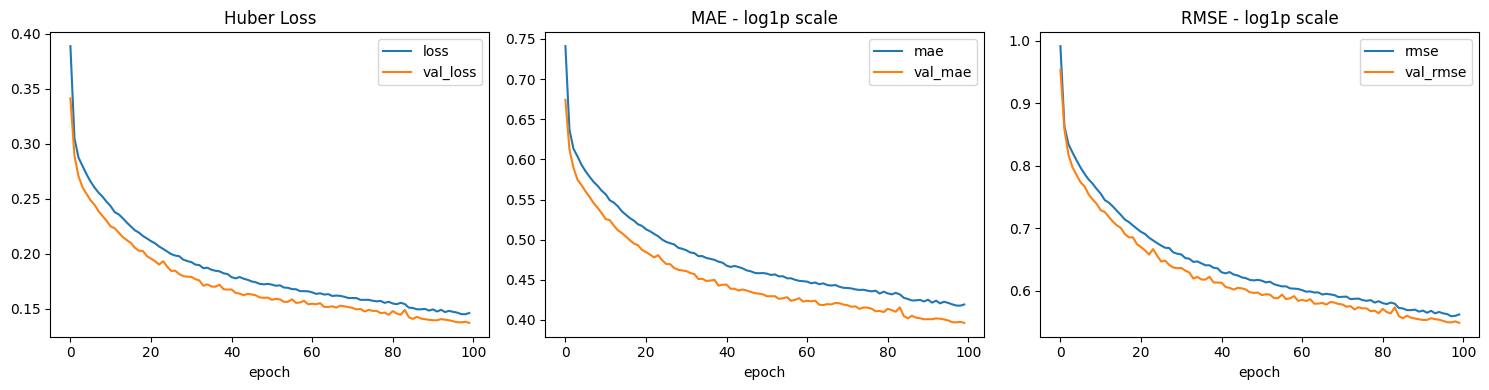

In [9]:
import matplotlib.pyplot as plt

history = pd.read_csv(history_path)
display(history.tail())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
history[["loss", "val_loss"]].plot(ax=axes[0], title="Huber Loss")
history[["mae", "val_mae"]].plot(ax=axes[1], title="MAE - log1p scale")
history[["rmse", "val_rmse"]].plot(ax=axes[2], title="RMSE - log1p scale")
for ax in axes:
    ax.set_xlabel("epoch")
plt.tight_layout()
plt.show()

In [10]:
predictions = pd.read_csv(predictions_path)
display(predictions.head())

print("예측 파일 크기:", predictions.shape)
print("실제 위험도 요약")
display(predictions["위험도"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame().T)
print("예측 위험도 요약")
display(predictions["pred_위험도"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame().T)

,POINT_ID,위도,경도,위험도,위험도_log1p,pred_위험도_log1p,pred_위험도
0,29,37.582845,126.999079,37.008,3.637797,3.279065,25.550940
1,31,37.571989,126.991741,5.488,1.869954,1.360678,2.898838
2,33,37.572045,126.992049,0.272,0.240590,0.913540,1.493134
3,41,37.573692,127.010329,9.888,2.387661,1.327958,2.773331
4,42,37.573681,127.010056,1.168,0.773805,0.920129,1.509613


예측 파일 크기: (13482, 7)
실제 위험도 요약


,count,mean,std,min,50%,75%,90%,95%,99%,max
위험도,13482.0,3.328545,9.227687,0.068,1.168,2.472,7.212,12.7,45.216,221.376


예측 위험도 요약


,count,mean,std,min,50%,75%,90%,95%,99%,max
pred_위험도,13482.0,2.015386,5.016985,0.0,0.852275,1.573583,3.82086,7.340824,22.10644,132.35674


/home/huichan/SPARV/SilverWalk/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/huichan/SPARV/SilverWalk/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/huichan/SPARV/SilverWalk/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


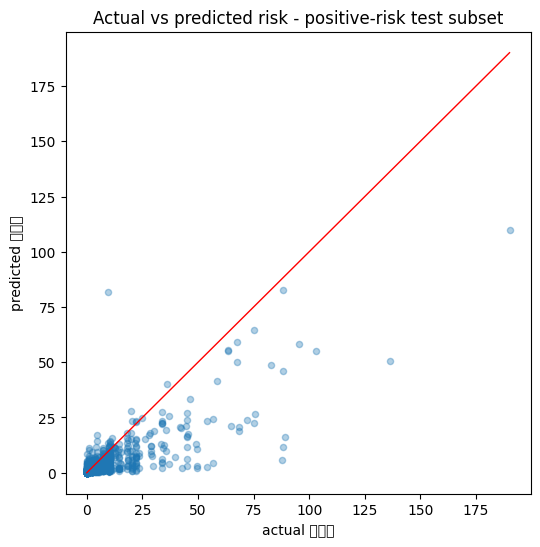

In [11]:
sample = predictions.sample(min(3000, len(predictions)), random_state=42)
ax = sample.plot.scatter(
    x="위험도",
    y="pred_위험도",
    alpha=0.35,
    figsize=(6, 6),
    title="Actual vs predicted risk - positive-risk test subset",
)
limit = max(sample["위험도"].max(), sample["pred_위험도"].max())
ax.plot([0, limit], [0, limit], color="red", linewidth=1)
ax.set_xlabel("actual 위험도")
ax.set_ylabel("predicted 위험도")
plt.show()

In [12]:
top_actual = predictions.sort_values("위험도", ascending=False).head(30)
display(top_actual[["POINT_ID", "위도", "경도", "위험도", "pred_위험도", "위험도_log1p", "pred_위험도_log1p"]])

top_predicted = predictions.sort_values("pred_위험도", ascending=False).head(30)
display(top_predicted[["POINT_ID", "위도", "경도", "위험도", "pred_위험도", "위험도_log1p", "pred_위험도_log1p"]])

,POINT_ID,위도,경도,위험도,pred_위험도,위험도_log1p,pred_위험도_log1p
6745,217588,37.588084,126.945012,221.376,132.356740,5.404370,4.893028
2681,97591,37.578803,127.038381,194.160,88.611900,5.273820,4.495488
7139,230762,37.588158,126.944881,190.080,109.832886,5.252692,4.708024
2633,95988,37.579919,127.040945,185.592,69.089770,5.228924,4.249777
3071,106874,37.598754,127.095305,164.808,100.960610,5.110830,4.624587
8143,267661,37.534136,126.847473,163.800,48.107872,5.104733,3.894019
7354,241996,37.539947,126.947400,148.032,9.902374,5.004161,2.388981
8583,281519,37.534131,126.847864,136.528,50.472744,4.923828,3.941052
2542,93789,37.579846,127.038443,120.008,87.684700,4.795857,4.485087
120,3147,37.570294,126.989441,117.920,59.486103,4.778451,4.102414


,POINT_ID,위도,경도,위험도,pred_위험도,위험도_log1p,pred_위험도_log1p
6745,217588,37.588084,126.945012,221.376,132.356740,5.404370,4.893028
7139,230762,37.588158,126.944881,190.080,109.832886,5.252692,4.708024
6990,226840,37.587895,126.945243,57.152,109.456980,4.063060,4.704626
3071,106874,37.598754,127.095305,164.808,100.960610,5.110830,4.624587
7137,230746,37.588383,126.944572,45.216,92.846980,3.833326,4.541666
2681,97591,37.578803,127.038381,194.160,88.611900,5.273820,4.495488
2542,93789,37.579846,127.038443,120.008,87.684700,4.795857,4.485087
12691,424298,37.492626,127.144192,88.440,82.856350,4.493568,4.429105
4040,136414,37.608498,127.010366,9.616,81.846924,2.362362,4.416995
3179,109625,37.588127,127.086469,103.272,69.635216,4.647003,4.257529
